In [1]:
"""
Market-Based EDA for QQQ Return Forecasting
============================================
Complements macro EDA by focusing purely on market-derived features:
  - QQQ return distribution & tail behavior
  - Volatility clustering (ARCH effects)
  - Autocorrelation structure of returns
  - Constituent return correlations (SPY, AAPL, NVDA, MSFT)
  - VIX regime analysis
  - Lagged return predictive power
  - Rolling feature stability over time
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import jarque_bera, kstest

import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller

In [2]:

# =============================================================================
# 0 — Data Loading (reuse same pipeline as final_v2.py)
# =============================================================================
print("=" * 65)
print("Loading data...")
print("=" * 65)

START, END = "2000-01-01", "2025-01-01"

qqq_raw = yf.download("QQQ", start=START, end=END, auto_adjust=True)
qqq_raw.columns = qqq_raw.columns.get_level_values(0)
qqq = qqq_raw[["Close"]].rename(columns={"Close": "QQQ"})
qqq.index = pd.to_datetime(qqq.index).tz_localize(None)

tech_raw = yf.download(["SPY","AAPL","NVDA","MSFT"], start=START, end=END, auto_adjust=True)
tech_close = tech_raw["Close"].copy()
tech_close.index = pd.to_datetime(tech_close.index).tz_localize(None)

vix_raw = yf.download("^VIX", start=START, end=END, auto_adjust=True)
vix_raw.columns = vix_raw.columns.get_level_values(0)
vix = vix_raw[["Close"]].rename(columns={"Close": "VIX"})
vix.index = pd.to_datetime(vix.index).tz_localize(None)

Loading data...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


In [3]:

# Build features
qqq["LOG_RETURN"]  = np.log(qqq["QQQ"]).diff()
qqq["ROLL_VOL21"]  = qqq["LOG_RETURN"].rolling(21).std()
qqq["ROLL_VOL63"]  = qqq["LOG_RETURN"].rolling(63).std()
qqq["RET_MA5"]     = qqq["LOG_RETURN"].rolling(5).mean()
qqq["RET_MA21"]    = qqq["LOG_RETURN"].rolling(21).mean()

tech_rets = np.log(tech_close).diff().rename(columns={
    "SPY":"SPY_RET","AAPL":"AAPL_RET","NVDA":"NVDA_RET","MSFT":"MSFT_RET"
})
vix["VIX_DIFF"] = vix["VIX"].diff()

df = qqq.join(tech_rets).join(vix).dropna()
ret = df["LOG_RETURN"]

print(f"  Loaded {len(df):,} trading days  ({df.index[0].date()} → {df.index[-1].date()})\n")

  Loaded 6,226 trading days  (2000-04-03 → 2024-12-31)



Plotting 1: Return distribution...


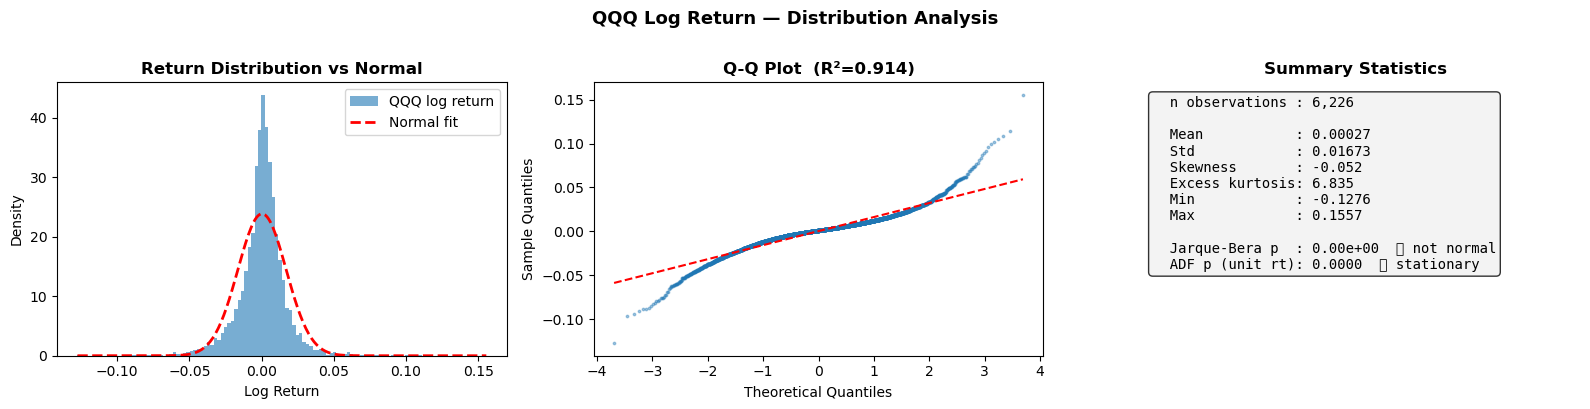

  Skewness=-0.052  Kurtosis=6.835  JB p=0.00e+00
  → Fat tails confirmed. Normal distribution assumption rejected.



In [7]:

# =============================================================================
# PLOT 1 — Return Distribution vs Normal
# =============================================================================
print("Plotting 1: Return distribution...")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
ax = axes[0]
mu, sigma = ret.mean(), ret.std()
x = np.linspace(ret.min(), ret.max(), 300)
ax.hist(ret, bins=120, density=True, color="#1f77b4", alpha=0.6, label="QQQ log return")
ax.plot(x, stats.norm.pdf(x, mu, sigma), "r--", linewidth=2, label="Normal fit")
ax.set_title("Return Distribution vs Normal", fontweight="bold")
ax.set_xlabel("Log Return"); ax.set_ylabel("Density")
ax.legend()

# Q-Q plot
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(ret, dist="norm")
ax.scatter(osm, osr, s=3, alpha=0.4, color="#1f77b4")
ax.plot(osm, slope * np.array(osm) + intercept, "r--", linewidth=1.5)
ax.set_title(f"Q-Q Plot  (R²={r**2:.3f})", fontweight="bold")
ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")

# Summary stats
ax = axes[2]
ax.axis("off")
jb_stat, jb_p = jarque_bera(ret.dropna())
adf_stat, adf_p, *_ = adfuller(ret.dropna())
stats_text = (
    f"  n observations : {len(ret):,}\n\n"
    f"  Mean           : {ret.mean():.5f}\n"
    f"  Std            : {ret.std():.5f}\n"
    f"  Skewness       : {ret.skew():.3f}\n"
    f"  Excess kurtosis: {ret.kurtosis():.3f}\n"
    f"  Min            : {ret.min():.4f}\n"
    f"  Max            : {ret.max():.4f}\n\n"
    f"  Jarque-Bera p  : {jb_p:.2e}  {'❌ not normal' if jb_p < 0.05 else '✅'}\n"
    f"  ADF p (unit rt): {adf_p:.4f}  {'✅ stationary' if adf_p < 0.05 else '⚠️ non-stationary'}"
)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))
ax.set_title("Summary Statistics", fontweight="bold")

plt.suptitle("QQQ Log Return — Distribution Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda1_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Skewness={ret.skew():.3f}  Kurtosis={ret.kurtosis():.3f}  JB p={jb_p:.2e}")
print(f"  → Fat tails confirmed. Normal distribution assumption rejected.\n")

Plotting 2: Autocorrelation & ARCH effects...


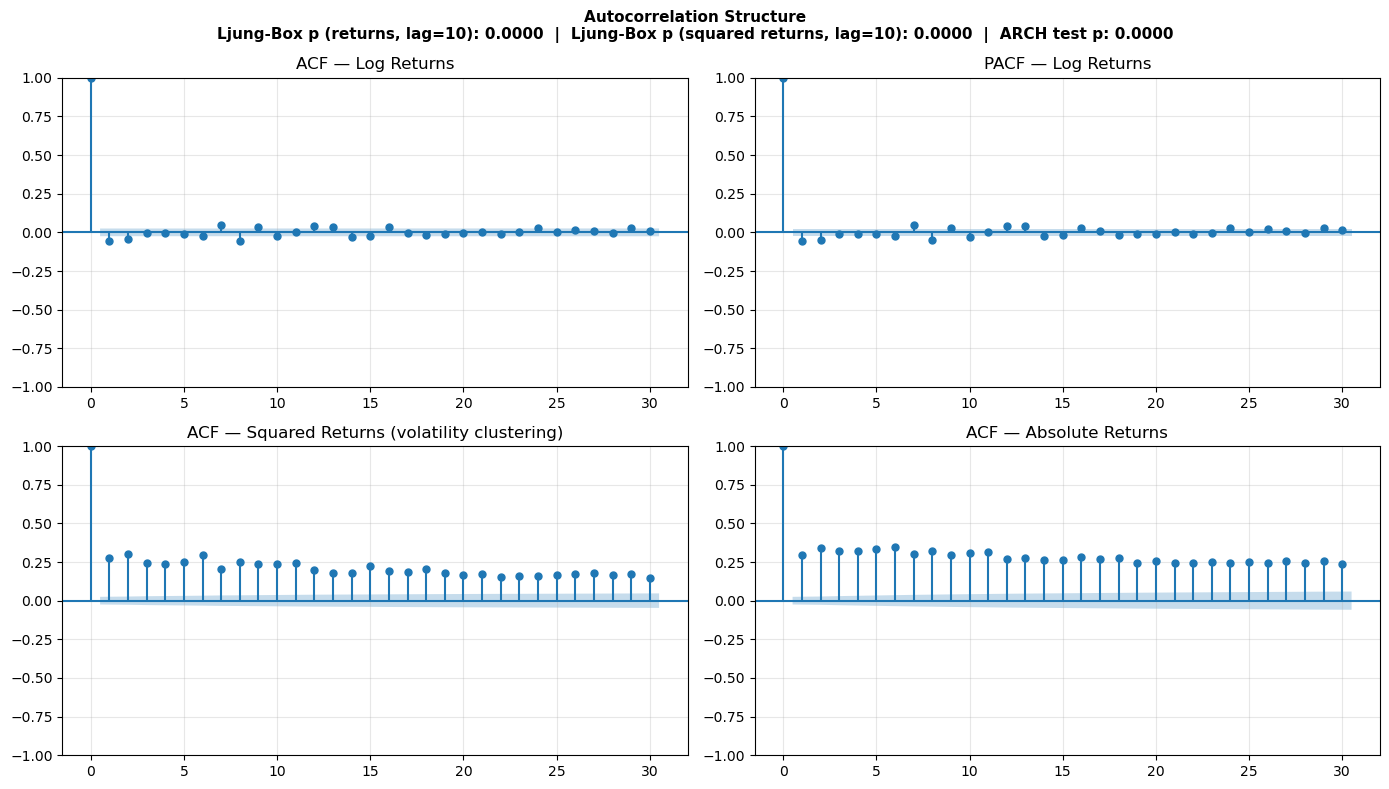

  Returns ACF p=0.0000  →  some autocorrelation in returns
  Squared returns ACF p=0.0000  →  ✅ strong ARCH effects — volatility clusters
  ARCH test p=0.0000  →  ✅ heteroskedasticity confirmed → rolling vol feature justified



In [8]:

# =============================================================================
# PLOT 2 — Autocorrelation of Returns & Squared Returns (ARCH effects)
# =============================================================================
print("Plotting 2: Autocorrelation & ARCH effects...")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(ret,         lags=30, ax=axes[0,0], title="ACF — Log Returns",         alpha=0.05)
plot_pacf(ret,        lags=30, ax=axes[0,1], title="PACF — Log Returns",        alpha=0.05)
plot_acf(ret**2,      lags=30, ax=axes[1,0], title="ACF — Squared Returns (volatility clustering)", alpha=0.05)
plot_acf(ret.abs(),   lags=30, ax=axes[1,1], title="ACF — Absolute Returns",    alpha=0.05)

for ax in axes.flat:
    ax.grid(alpha=0.3)

lb_ret  = acorr_ljungbox(ret,    lags=[10], return_df=True)["lb_pvalue"].iloc[0]
lb_ret2 = acorr_ljungbox(ret**2, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
arch_stat, arch_p, *_ = het_arch(ret.dropna())

plt.suptitle(
    f"Autocorrelation Structure\n"
    f"Ljung-Box p (returns, lag=10): {lb_ret:.4f}  |  "
    f"Ljung-Box p (squared returns, lag=10): {lb_ret2:.4f}  |  "
    f"ARCH test p: {arch_p:.4f}",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("eda2_autocorrelation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Returns ACF p={lb_ret:.4f}  →  {'little autocorrelation in returns (expected)' if lb_ret > 0.05 else 'some autocorrelation in returns'}")
print(f"  Squared returns ACF p={lb_ret2:.4f}  →  {'✅ strong ARCH effects — volatility clusters' if lb_ret2 < 0.05 else 'no ARCH effects'}")
print(f"  ARCH test p={arch_p:.4f}  →  {'✅ heteroskedasticity confirmed → rolling vol feature justified' if arch_p < 0.05 else 'no ARCH'}\n")

Plotting 3: Rolling volatility over time...


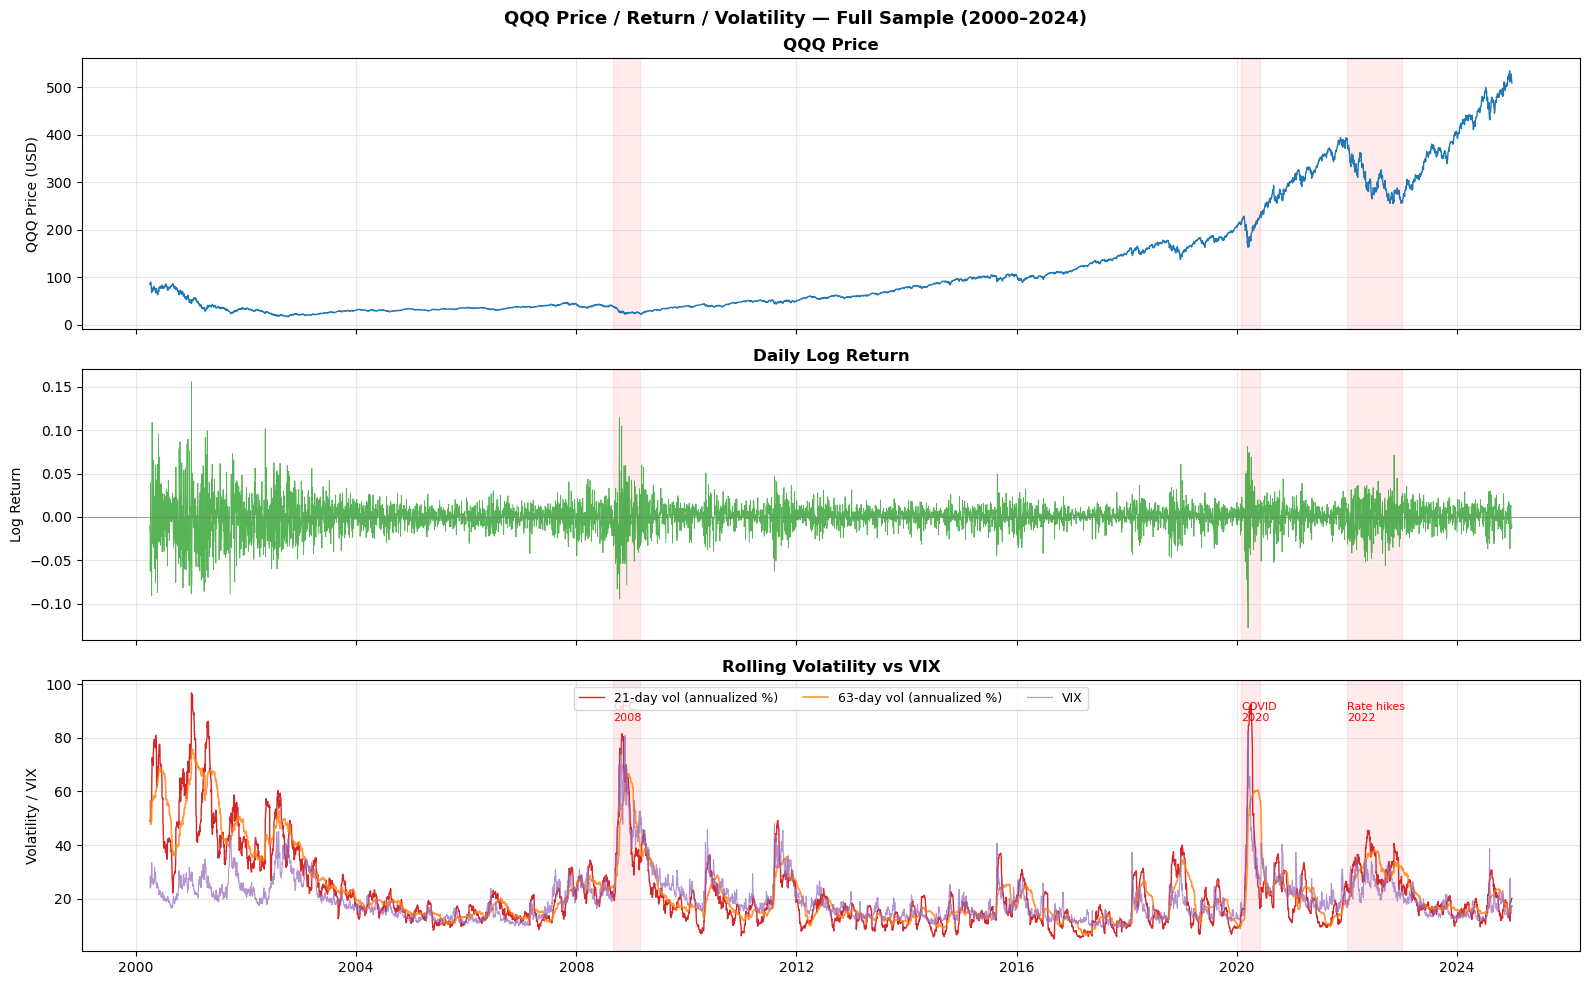

  → Volatility clustering clearly visible. Rolling vol and VIX move together.



In [9]:

# =============================================================================
# PLOT 3 — Volatility Over Time
# =============================================================================
print("Plotting 3: Rolling volatility over time...")

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

ax = axes[0]
ax.plot(df.index, df["QQQ"], color="#1f77b4", linewidth=1)
ax.set_ylabel("QQQ Price (USD)"); ax.set_title("QQQ Price", fontweight="bold")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df.index, ret, color="#2ca02c", linewidth=0.6, alpha=0.8)
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_ylabel("Log Return"); ax.set_title("Daily Log Return", fontweight="bold")
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(df.index, df["ROLL_VOL21"] * np.sqrt(252) * 100, color="#d62728", linewidth=1,   label="21-day vol (annualized %)")
ax.plot(df.index, df["ROLL_VOL63"] * np.sqrt(252) * 100, color="#ff7f0e", linewidth=1.2, label="63-day vol (annualized %)", alpha=0.8)
ax.plot(df.index, df["VIX"],                              color="#9467bd", linewidth=0.8, label="VIX", alpha=0.7)
ax.set_ylabel("Volatility / VIX"); ax.set_title("Rolling Volatility vs VIX", fontweight="bold")
ax.legend(fontsize=9, ncol=3); ax.grid(alpha=0.3)

# Mark crises
crises = {
    "GFC\n2008": ("2008-09-01", "2009-03-01"),
    "COVID\n2020": ("2020-02-01", "2020-06-01"),
    "Rate hikes\n2022": ("2022-01-01", "2022-12-31"),
}
for label, (s, e) in crises.items():
    for a in axes:
        a.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color="red")
    axes[2].text(pd.Timestamp(s), axes[2].get_ylim()[1]*0.85, label, fontsize=8, color="red")

plt.suptitle("QQQ Price / Return / Volatility — Full Sample (2000–2024)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda3_volatility_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Volatility clustering clearly visible. Rolling vol and VIX move together.\n")

Plotting 4: VIX regime analysis...


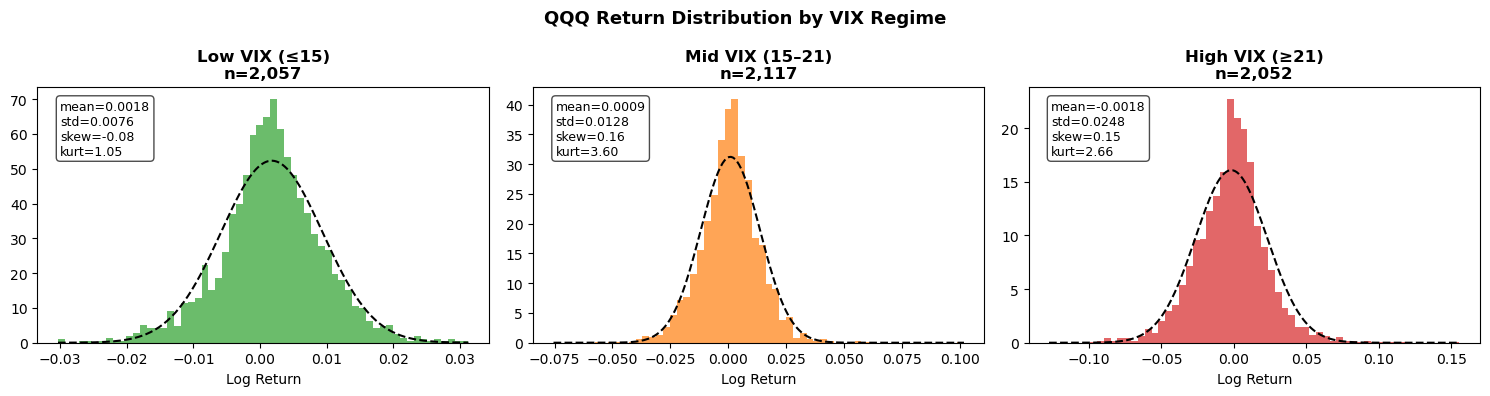

  Low VIX  — std=0.0076  kurt=1.05
  Mid VIX  — std=0.0128  kurt=3.60
  High VIX — std=0.0248  kurt=2.66
  → Volatility scales sharply with VIX regime. VIX is a strong conditioning variable.



In [10]:

# =============================================================================
# PLOT 4 — VIX Regime Analysis
# =============================================================================
print("Plotting 4: VIX regime analysis...")

# Split into low / mid / high VIX regimes
vix_vals = df["VIX"]
low_vix  = ret[vix_vals <= vix_vals.quantile(0.33)]
mid_vix  = ret[(vix_vals > vix_vals.quantile(0.33)) & (vix_vals <= vix_vals.quantile(0.67))]
high_vix = ret[vix_vals > vix_vals.quantile(0.67)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colors = ["#2ca02c", "#ff7f0e", "#d62728"]
labels = [
    f"Low VIX (≤{vix_vals.quantile(0.33):.0f})\nn={len(low_vix):,}",
    f"Mid VIX ({vix_vals.quantile(0.33):.0f}–{vix_vals.quantile(0.67):.0f})\nn={len(mid_vix):,}",
    f"High VIX (≥{vix_vals.quantile(0.67):.0f})\nn={len(high_vix):,}",
]
for ax, data, col, lbl in zip(axes, [low_vix, mid_vix, high_vix], colors, labels):
    ax.hist(data, bins=60, density=True, color=col, alpha=0.7)
    mu_r, std_r = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu_r, std_r), "k--", linewidth=1.5)
    ax.set_title(lbl, fontweight="bold")
    ax.set_xlabel("Log Return")
    ax.text(0.05, 0.95,
            f"mean={mu_r:.4f}\nstd={std_r:.4f}\nskew={data.skew():.2f}\nkurt={data.kurtosis():.2f}",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.suptitle("QQQ Return Distribution by VIX Regime", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda4_vix_regime.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"  Low VIX  — std={low_vix.std():.4f}  kurt={low_vix.kurtosis():.2f}")
print(f"  Mid VIX  — std={mid_vix.std():.4f}  kurt={mid_vix.kurtosis():.2f}")
print(f"  High VIX — std={high_vix.std():.4f}  kurt={high_vix.kurtosis():.2f}")
print(f"  → Volatility scales sharply with VIX regime. VIX is a strong conditioning variable.\n")

Plotting 5: Constituent correlations...


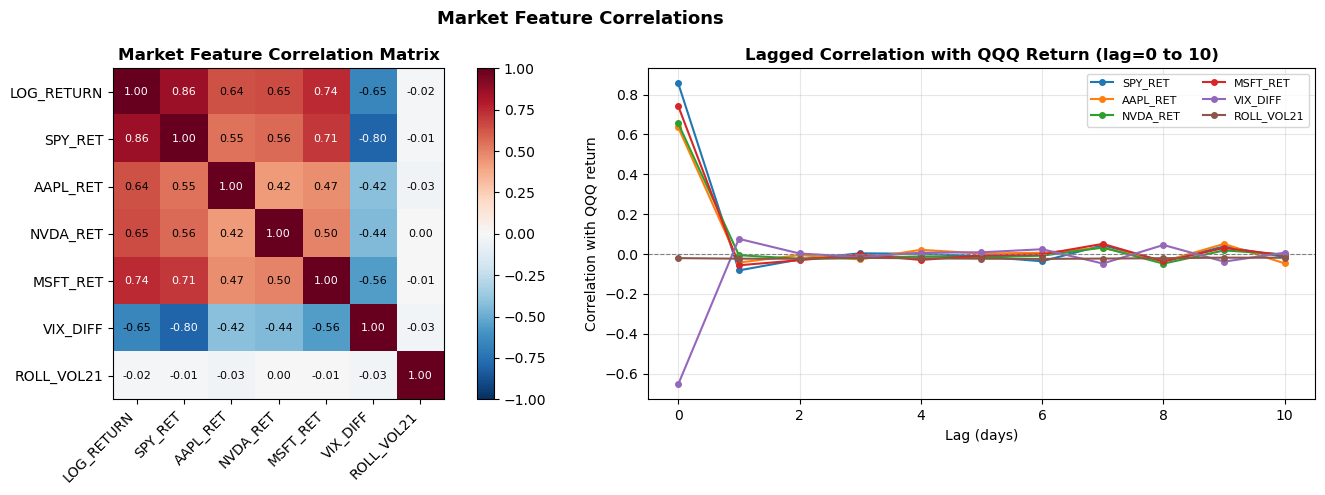

  Contemporaneous correlations with QQQ return:
    SPY_RET         r = 0.856
    AAPL_RET        r = 0.635
    NVDA_RET        r = 0.655
    MSFT_RET        r = 0.742
    VIX_DIFF        r = -0.654
    ROLL_VOL21      r = -0.021



In [11]:

# =============================================================================
# PLOT 5 — Constituent Returns Correlation with QQQ
# =============================================================================
print("Plotting 5: Constituent correlations...")

market_cols = ["LOG_RETURN", "SPY_RET", "AAPL_RET", "NVDA_RET", "MSFT_RET", "VIX_DIFF", "ROLL_VOL21"]
corr = df[market_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Correlation heatmap
ax = axes[0]
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(market_cols))); ax.set_xticklabels(market_cols, rotation=45, ha="right")
ax.set_yticks(range(len(market_cols))); ax.set_yticklabels(market_cols)
for i in range(len(market_cols)):
    for j in range(len(market_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color="black" if abs(corr.iloc[i,j]) < 0.7 else "white")
plt.colorbar(im, ax=ax)
ax.set_title("Market Feature Correlation Matrix", fontweight="bold")

# Lagged correlation: each feature vs QQQ return at various lags
ax = axes[1]
lag_features = ["SPY_RET", "AAPL_RET", "NVDA_RET", "MSFT_RET", "VIX_DIFF", "ROLL_VOL21"]
lags = range(0, 11)
for feat in lag_features:
    lag_corrs = [df["LOG_RETURN"].corr(df[feat].shift(lag)) for lag in lags]
    ax.plot(lags, lag_corrs, marker="o", markersize=4, label=feat)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Lag (days)"); ax.set_ylabel("Correlation with QQQ return")
ax.set_title("Lagged Correlation with QQQ Return (lag=0 to 10)", fontweight="bold")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.suptitle("Market Feature Correlations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda5_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("  Contemporaneous correlations with QQQ return:")
for feat in lag_features:
    print(f"    {feat:<15} r = {df['LOG_RETURN'].corr(df[feat]):.3f}")
print()

Plotting 6: Lagged return predictability...


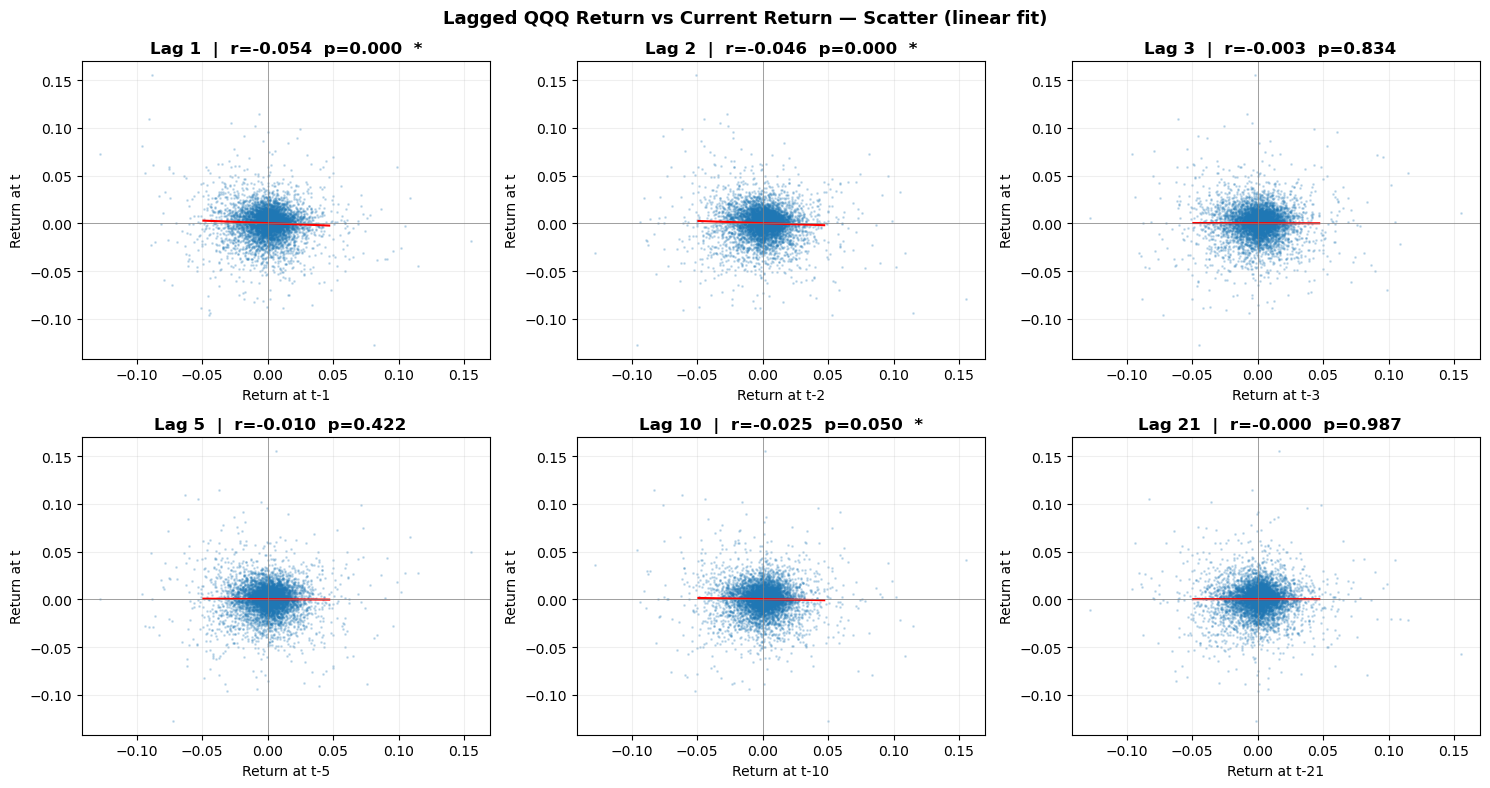

  Linear predictability of lagged returns:
    Lag  1  r=-0.0537  p=0.0000  * significant
    Lag  2  r=-0.0461  p=0.0003  * significant
    Lag  3  r=-0.0027  p=0.8337    not significant
    Lag  5  r=-0.0102  p=0.4220    not significant
    Lag 10  r=-0.0249  p=0.0495  * significant
    Lag 21  r=-0.0002  p=0.9869    not significant



In [12]:

# =============================================================================
# PLOT 6 — Lagged Return Predictability (can past returns predict today?)
# =============================================================================
print("Plotting 6: Lagged return predictability...")

lags_to_check = [1, 2, 3, 5, 10, 21]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, lag in zip(axes.flat, lags_to_check):
    lagged = df["LOG_RETURN"].shift(lag)
    valid  = df["LOG_RETURN"].notna() & lagged.notna()
    x, y   = lagged[valid], df["LOG_RETURN"][valid]
    slope, intercept, r, p, _ = stats.linregress(x, y)

    ax.scatter(x, y, s=1, alpha=0.2, color="#1f77b4")
    xline = np.linspace(x.quantile(0.01), x.quantile(0.99), 100)
    ax.plot(xline, slope * xline + intercept, "r-", linewidth=1.5)
    ax.set_title(f"Lag {lag}  |  r={r:.3f}  p={p:.3f}  {'*' if p < 0.05 else ''}",
                 fontweight="bold")
    ax.set_xlabel(f"Return at t-{lag}"); ax.set_ylabel("Return at t")
    ax.axhline(0, color="gray", linewidth=0.5); ax.axvline(0, color="gray", linewidth=0.5)
    ax.grid(alpha=0.2)

plt.suptitle("Lagged QQQ Return vs Current Return — Scatter (linear fit)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda6_lag_predictability.png", dpi=150, bbox_inches="tight")
plt.show()

print("  Linear predictability of lagged returns:")
for lag in lags_to_check:
    lagged = df["LOG_RETURN"].shift(lag)
    valid  = df["LOG_RETURN"].notna() & lagged.notna()
    _, _, r, p, _ = stats.linregress(lagged[valid], df["LOG_RETURN"][valid])
    sig = "* significant" if p < 0.05 else "  not significant"
    print(f"    Lag {lag:>2}  r={r:+.4f}  p={p:.4f}  {sig}")
print()

Plotting 7: Directional accuracy of lagged returns...


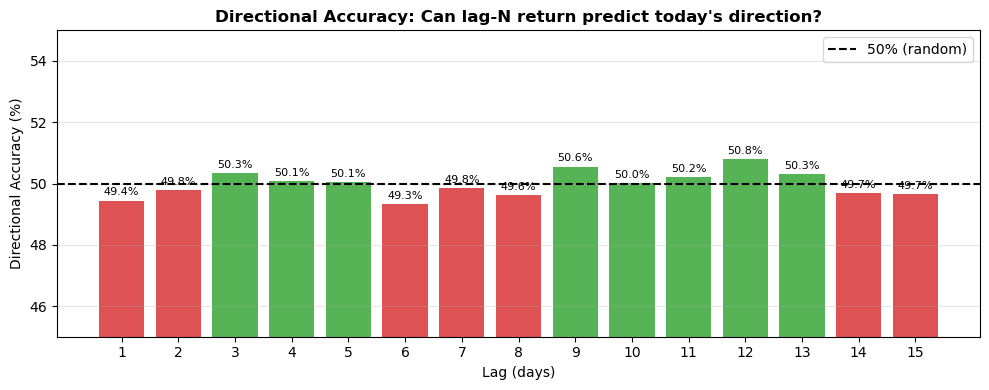

  Best directional accuracy: lag 12 at 50.79%
  → Returns are largely unpredictable in direction (near 50%).
    This is expected. Models need to capture non-linear patterns.



In [13]:

# =============================================================================
# PLOT 7 — Directional Accuracy of Lagged Returns (sign prediction)
# =============================================================================
print("Plotting 7: Directional accuracy of lagged returns...")

lags  = range(1, 16)
d_acc = []
for lag in lags:
    lagged = df["LOG_RETURN"].shift(lag)
    valid  = df["LOG_RETURN"].notna() & lagged.notna()
    acc    = np.mean(np.sign(df["LOG_RETURN"][valid]) == np.sign(lagged[valid])) * 100
    d_acc.append(acc)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(lags, d_acc, color=["#d62728" if a < 50 else "#2ca02c" for a in d_acc], alpha=0.8)
ax.axhline(50, color="black", linestyle="--", linewidth=1.5, label="50% (random)")
ax.set_xlabel("Lag (days)"); ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("Directional Accuracy: Can lag-N return predict today's direction?",
             fontweight="bold")
ax.set_ylim(45, 55); ax.set_xticks(list(lags))
ax.legend(); ax.grid(alpha=0.3, axis="y")
for bar, val in zip(bars, d_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("eda7_directional_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

best_lag = lags[np.argmax(d_acc)]
print(f"  Best directional accuracy: lag {best_lag} at {max(d_acc):.2f}%")
print(f"  → Returns are largely unpredictable in direction (near 50%).")
print(f"    This is expected. Models need to capture non-linear patterns.\n")

Plotting 8: Rolling correlations over time...


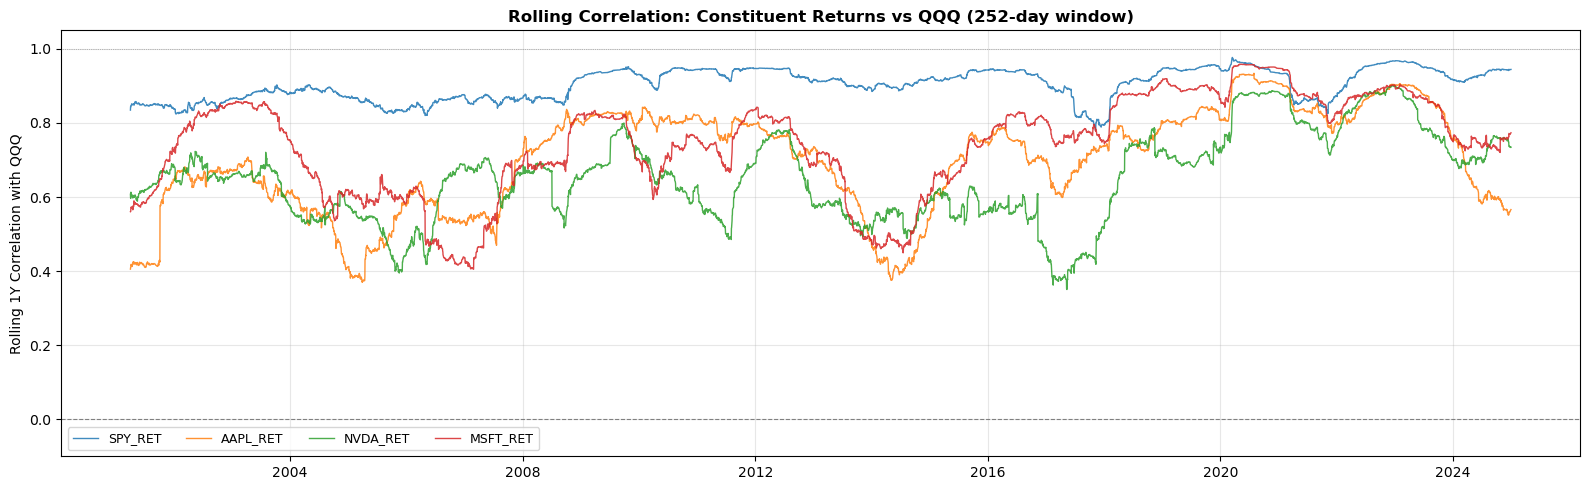

  → Correlations are high but time-varying — non-constant relationships justify using a neural net.



In [14]:

# =============================================================================
# PLOT 8 — Rolling Correlation: Constituents vs QQQ over time
# =============================================================================
print("Plotting 8: Rolling correlations over time...")

WINDOW = 252  # 1-year rolling window
fig, ax = plt.subplots(figsize=(16, 5))

for feat, col in zip(
    ["SPY_RET", "AAPL_RET", "NVDA_RET", "MSFT_RET"],
    ["#1f77b4",  "#ff7f0e",  "#2ca02c",  "#d62728"]
):
    roll_corr = df["LOG_RETURN"].rolling(WINDOW).corr(df[feat])
    ax.plot(df.index, roll_corr, linewidth=1, label=feat, color=col, alpha=0.85)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(1, color="gray", linestyle=":",  linewidth=0.5)
ax.set_ylabel("Rolling 1Y Correlation with QQQ")
ax.set_title("Rolling Correlation: Constituent Returns vs QQQ (252-day window)",
             fontweight="bold")
ax.legend(fontsize=9, ncol=4); ax.grid(alpha=0.3)
ax.set_ylim(-0.1, 1.05)

plt.tight_layout()
plt.savefig("eda8_rolling_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Correlations are high but time-varying — non-constant relationships justify using a neural net.\n")